In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [26]:
cleaned_path = 'Assignment 1 (Advanced)/data/dataset_mood_smartphone_cleaned.csv'
daily_df = pd.read_csv(cleaned_path)
daily_df.head()

,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.other,appCat.social,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-17,0.081548,5.521377,7.682127,5.863222,2.513251,6.695466,2.0,-0.25,0.75,6.25,7.730589,2.0
1,AS14.01,2014-02-18,0.081548,5.521377,7.682127,5.863222,2.513251,6.695466,1.0,-0.25,0.75,6.25,7.730589,2.0
2,AS14.01,2014-02-19,0.081548,5.521377,7.682127,5.863222,2.513251,6.695466,7.0,-0.25,0.75,6.25,7.730589,2.0
3,AS14.01,2014-02-20,0.081548,5.521377,7.682127,5.863222,2.513251,6.695466,2.0,-0.25,0.75,6.25,7.730589,3.0
4,AS14.01,2014-02-21,0.081548,5.521377,7.682127,5.863222,2.513251,6.695466,2.0,-0.25,0.75,6.25,7.730589,1.0


## Sliding Window Feature Engineering from Claude

This code varifies the importance of the mood lags. I kept this in to validate for later when the code is actually cleaned.
Deze code bevestigt de nut van de mood lags. Ik heb hem erin gehouden om later m'n methode te bevestigen en omdat deze code de average rolling mood maakt van 7 dagen die ik nodig heb.


For each patient, we slide a window of `W` days over their daily time series. From each window we extract:

- **Aggregation features**: mean, std, min, max of each variable over the window
- **Trend features**: linear slope of each variable over the window (captures direction of change)
- **Lag features**: mood values from the previous 1, 2, and 3 days
- **Temporal features**: day of the week (cyclical encoding)
- **Target**: the average mood on the *next* day after the window

In [6]:
# Configuration
WINDOW_SIZE = 7  # number of days in the history window
N_LAGS = 3       # number of mood lag features

# Feature columns (all variables except id and date)
feature_vars = [c for c in daily_df.columns if c not in ['id', 'date']]

In [7]:
def compute_slope(series):
    """Compute linear trend (slope) over a series. Returns NaN if not enough data."""
    y = series.dropna()
    if len(y) < 2:
        return np.nan
    x = np.arange(len(y))
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope


def build_sliding_window_features(patient_df, feature_vars, window_size, n_lags):
    """
    Build feature rows from a single patient's daily data using a sliding window.
    
    For each valid position t (where we have window_size days of history and
    a next-day target), we create one instance with:
    - Rolling aggregation features (mean, std, min, max) over the window
    - Trend (slope) over the window
    - Lag features for mood
    - Day-of-week (sin/cos encoded)
    - Target: next-day mood
    """
    patient_df = patient_df.sort_values('date').reset_index(drop=True)
    n_days = len(patient_df)
    instances = []

    for t in range(window_size, n_days):
        # Window: days [t - window_size, t) ; Target: day t
        window = patient_df.iloc[t - window_size : t]
        target_row = patient_df.iloc[t]

        # Skip if target mood is missing
        if pd.isna(target_row['mood']):
            continue

        row = {
            'id': patient_df.iloc[t]['id'],
            'date': target_row['date'],
            'target_mood': target_row['mood'],
        }

        # Aggregation features over the window
        for var in feature_vars:
            vals = window[var]
            row[f'{var}_mean'] = vals.mean()
            row[f'{var}_std'] = vals.std()
            row[f'{var}_min'] = vals.min()
            row[f'{var}_max'] = vals.max()
            row[f'{var}_trend'] = compute_slope(vals)

        # Lag features for mood (mood on day t-1, t-2, t-3, ...)
        for lag in range(1, n_lags + 1):
            lag_idx = t - lag
            if lag_idx >= 0:
                row[f'mood_lag{lag}'] = patient_df.iloc[lag_idx]['mood']
            else:
                row[f'mood_lag{lag}'] = np.nan

        # Day-of-week features (cyclical encoding)
        target_date = pd.to_datetime(target_row['date'])
        dow = target_date.dayofweek  # 0=Monday, 6=Sunday
        row['dow_sin'] = np.sin(2 * np.pi * dow / 7)
        row['dow_cos'] = np.cos(2 * np.pi * dow / 7)

        instances.append(row)

    return pd.DataFrame(instances)


print("Feature engineering function defined.")

Feature engineering function defined.


In [8]:
# Apply sliding window feature engineering per patient
patient_ids = sorted(daily_df['id'].unique())
all_instances = []

for pid in patient_ids:
    patient_data = daily_df[daily_df['id'] == pid].copy()
    patient_features = build_sliding_window_features(
        patient_data, feature_vars, WINDOW_SIZE, N_LAGS
    )
    all_instances.append(patient_features)

features_df = pd.concat(all_instances, ignore_index=True)

print(f"Total instances created: {len(features_df)}")
print(f"Patients represented: {features_df['id'].nunique()}")
print(f"Instances per patient:")
print(features_df.groupby('id').size().describe())
print(f"\nTotal features: {len([c for c in features_df.columns if c not in ['id', 'date', 'target_mood']])})")

Total instances created: 1965
Patients represented: 27
Instances per patient:
count    27.000000
mean     72.777778
std      10.437850
min      43.000000
25%      70.500000
50%      71.000000
75%      74.000000
max      97.000000
dtype: float64

Total features: 65)


In [33]:
# Preview the feature matrix
print("Feature columns:")
feature_cols = [c for c in features_df.columns if c not in ['id', 'date', 'target_mood']]
for i, col in enumerate(feature_cols):
    print(f"  {i+1:3d}. {col}")

print(f"\nTarget distribution:")
print(features_df['target_mood'].describe())
features_df.head()

Feature columns:
    1. activity_mean
    2. activity_std
    3. activity_min
    4. activity_max
    5. activity_trend
    6. appCat.builtin_mean
    7. appCat.builtin_std
    8. appCat.builtin_min
    9. appCat.builtin_max
   10. appCat.builtin_trend
   11. appCat.communication_mean
   12. appCat.communication_std
   13. appCat.communication_min
   14. appCat.communication_max
   15. appCat.communication_trend
   16. appCat.entertainment_mean
   17. appCat.entertainment_std
   18. appCat.entertainment_min
   19. appCat.entertainment_max
   20. appCat.entertainment_trend
   21. appCat.other_mean
   22. appCat.other_std
   23. appCat.other_min
   24. appCat.other_max
   25. appCat.other_trend
   26. appCat.social_mean
   27. appCat.social_std
   28. appCat.social_min
   29. appCat.social_max
   30. appCat.social_trend
   31. call_mean
   32. call_std
   33. call_min
   34. call_max
   35. call_trend
   36. circumplex.arousal_mean
   37. circumplex.arousal_std
   38. circumplex.arousal_

,id,date,target_mood,activity_mean,activity_std,activity_min,activity_max,activity_trend,appCat.builtin_mean,appCat.builtin_std,...,sms_mean,sms_std,sms_min,sms_max,sms_trend,mood_lag1,mood_lag2,mood_lag3,dow_sin,dow_cos
0,AS14.01,2014-02-24,6.250000,0.081548,0.0,0.081548,0.081548,0.0,5.521377,0.0,...,1.750000,0.721688,1.0,3.0,-0.187500,6.250000,6.25,6.25,0.000000,1.000000
1,AS14.01,2014-02-25,6.250000,0.081548,0.0,0.081548,0.081548,0.0,5.521377,0.0,...,1.678571,0.717552,1.0,3.0,-0.178571,6.250000,6.25,6.25,0.781831,0.623490
2,AS14.01,2014-02-26,6.250000,0.081548,0.0,0.081548,0.081548,0.0,5.521377,0.0,...,1.642857,0.704999,1.0,3.0,-0.125000,6.250000,6.25,6.25,0.974928,-0.222521
3,AS14.01,2014-02-27,6.333333,0.081548,0.0,0.081548,0.081548,0.0,5.521377,0.0,...,1.642857,0.704999,1.0,3.0,-0.035714,6.250000,6.25,6.25,0.433884,-0.900969
4,AS14.01,2014-02-28,6.327273,0.081548,0.0,0.081548,0.081548,0.0,5.521377,0.0,...,1.452381,0.384470,1.0,2.0,0.160714,6.333333,6.25,6.25,-0.433884,-0.900969


In [11]:
# Compute correlations between all features and the target
feature_cols = [c for c in features_df.columns if c not in ['id', 'date', 'target_mood']]
correlations = features_df[feature_cols].corrwith(features_df['target_mood']).sort_values(ascending=False)

# Show top 20 positively and negatively correlated features
print("Top 20 features most POSITIVELY correlated with next-day mood:")
print(correlations.head(20).to_string())
print(f"\nTop 20 features most NEGATIVELY correlated with next-day mood:")
print(correlations.tail(20).to_string())

Top 20 features most POSITIVELY correlated with next-day mood:
mood_mean                    0.756860
mood_lag1                    0.721572
mood_lag2                    0.666815
mood_min                     0.648087
mood_max                     0.619209
mood_lag3                    0.613244
circumplex.valence_mean      0.507710
circumplex.valence_min       0.448186
circumplex.valence_max       0.428340
activity_min                 0.189490
appCat.other_mean            0.160061
activity_mean                0.156564
appCat.other_min             0.150483
appCat.entertainment_min     0.134499
appCat.other_max             0.133862
appCat.communication_min     0.103973
appCat.entertainment_mean    0.096488
sms_min                      0.096389
mood_trend                   0.083524
activity_max                 0.081794

Top 20 features most NEGATIVELY correlated with next-day mood:
call_max                   -0.034163
call_mean                  -0.036405
appCat.other_std           -0.043305
sm

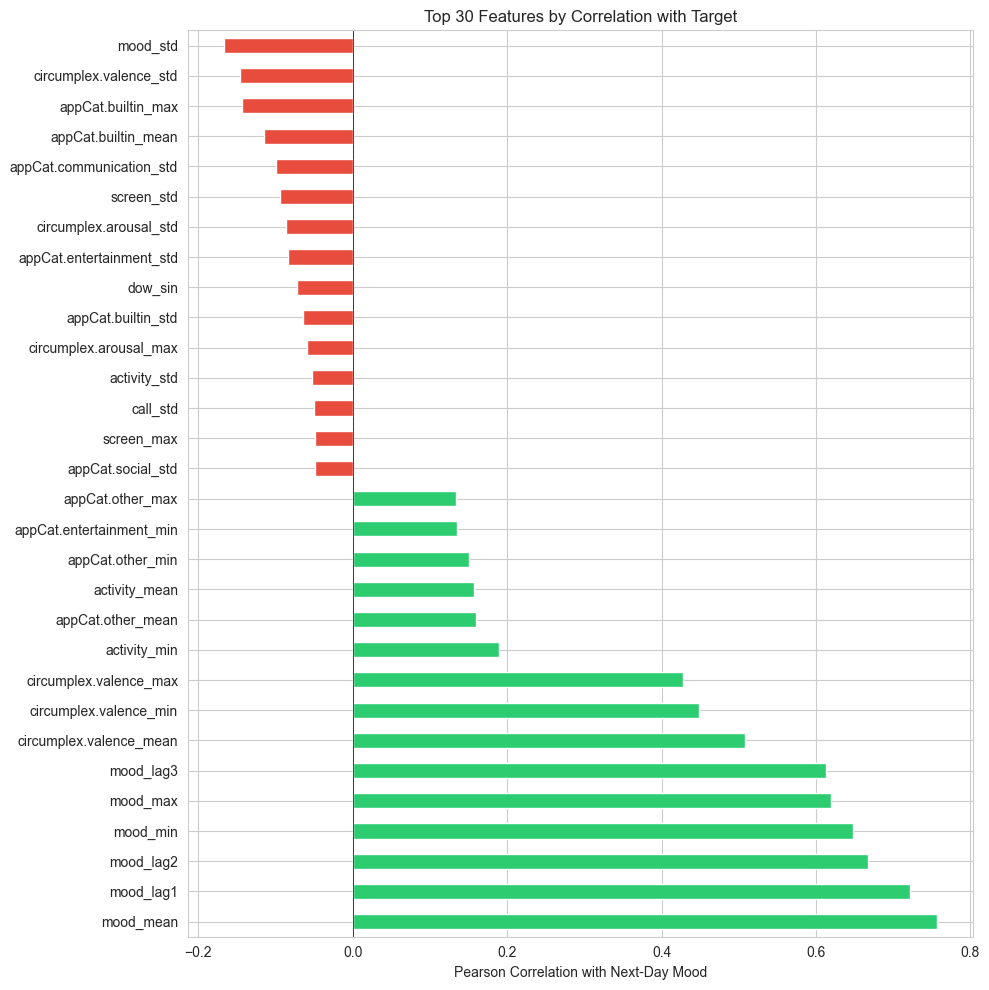

In [12]:
# Visualize top correlated features
top_n = 30
top_corr = pd.concat([correlations.head(top_n // 2), correlations.tail(top_n // 2)])

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Pearson Correlation with Next-Day Mood')
ax.set_title(f'Top {top_n} Features by Correlation with Target')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [13]:
# Feature importance using a quick Random Forest
from sklearn.ensemble import RandomForestRegressor

X = features_df[feature_cols].copy()
y = features_df['target_mood'].copy()

# Drop any columns that are all NaN or constant
valid_cols = X.columns[X.std() > 0]
X = X[valid_cols]

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 20 features by Random Forest importance:")
print(importances.head(20).to_string())
print(f"\nRF R-squared (training, for reference): {rf.score(X, y):.3f}")

Top 20 features by Random Forest importance:
mood_mean                     0.442227
mood_lag1                     0.144854
mood_lag2                     0.019848
mood_min                      0.018541
mood_lag3                     0.013624
circumplex.arousal_trend      0.013016
mood_trend                    0.012939
appCat.entertainment_trend    0.011263
activity_min                  0.010807
activity_trend                0.009498
mood_max                      0.009222
circumplex.valence_trend      0.008781
appCat.builtin_trend          0.008608
circumplex.valence_mean       0.008605
call_trend                    0.008590
appCat.social_trend           0.008231
activity_std                  0.008028
mood_std                      0.007782
appCat.communication_trend    0.007669
screen_trend                  0.007513

RF R-squared (training, for reference): 0.946


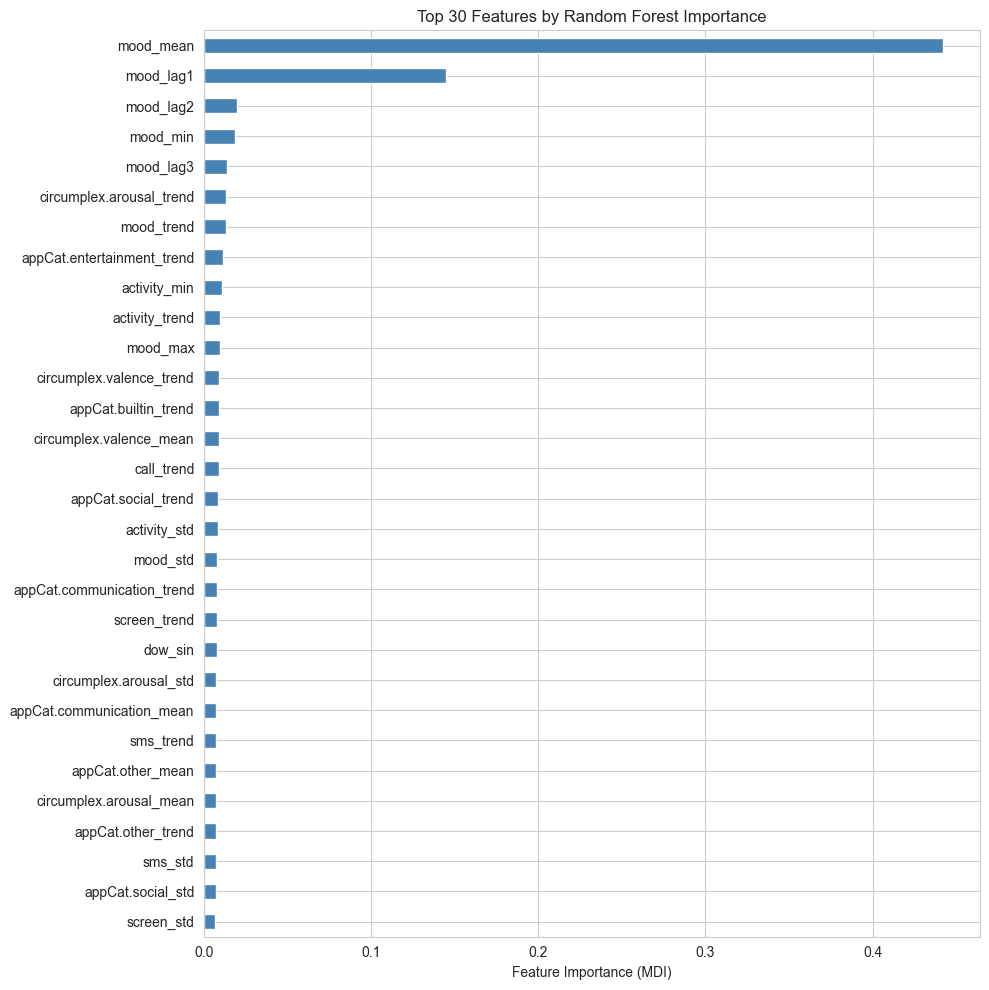

In [14]:
# Visualize Random Forest feature importances
fig, ax = plt.subplots(figsize=(10, 10))
importances.head(30).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (MDI)')
ax.set_title('Top 30 Features by Random Forest Importance')
plt.tight_layout()
plt.show()

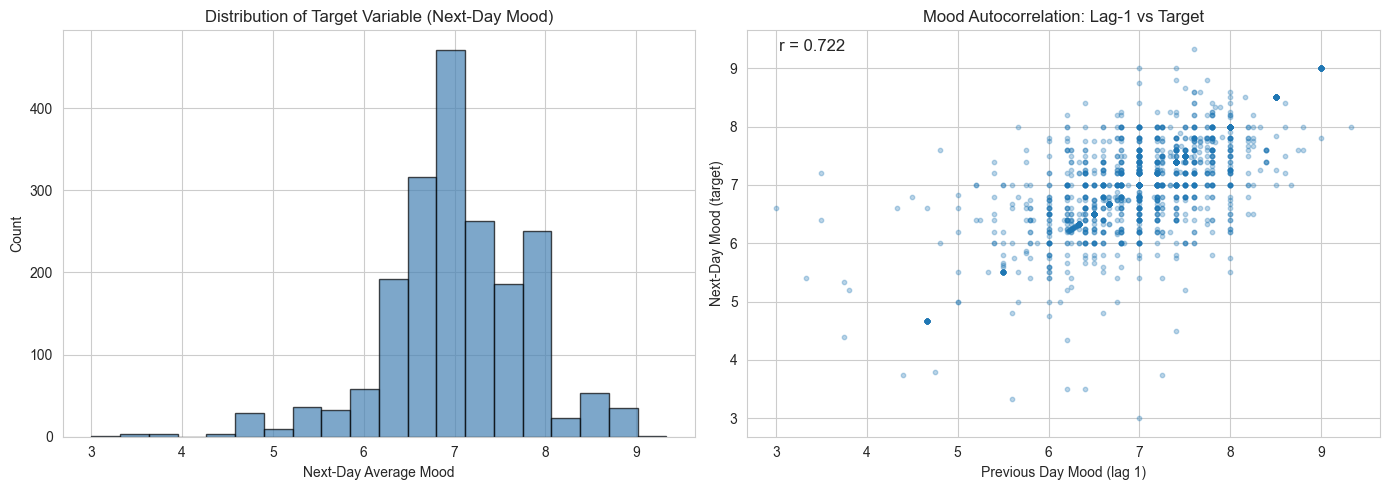

In [15]:
# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(features_df['target_mood'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Next-Day Average Mood')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target Variable (Next-Day Mood)')

# Scatter: mood_lag1 vs target
axes[1].scatter(features_df['mood_lag1'], features_df['target_mood'], alpha=0.3, s=10)
axes[1].set_xlabel('Previous Day Mood (lag 1)')
axes[1].set_ylabel('Next-Day Mood (target)')
axes[1].set_title('Mood Autocorrelation: Lag-1 vs Target')
r = features_df[['mood_lag1', 'target_mood']].corr().iloc[0, 1]
axes[1].annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)

plt.tight_layout()
plt.show()

## Statistical Lag Analysis of Mood

1. **ACF** 
2. **PACF** 
3. **ADF test** 
4. **Ljung-Box test**

In [16]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as scipy_stats
import matplotlib.gridspec as gridspec         


In [17]:
mood_series_by_patient = {}
for pid, grp in daily_df.groupby('id'):
    s = grp.sort_values('date')['mood'].reset_index(drop=True)
    mood_series_by_patient[pid] = s.dropna()

pooled_mood = pd.concat(
    [s - s.mean() for s in mood_series_by_patient.values()],
    ignore_index=True
)


In [18]:
# Augmented Dickey-Fuller Stationarity Test
# To test the stationarity of each mood series such that ACF/PACF assumptions hold.
print("=" * 60)
print("ADF Stationarity Test — per patient (mood series)")
print("=" * 60)

adf_results = []
for pid, s in mood_series_by_patient.items():
    if len(s) < 10:
        continue
    adf_stat, p_val, _, _, crit, _ = adfuller(s, autolag='AIC')
    adf_results.append({
        'patient': pid,
        'ADF_stat': round(adf_stat, 3),
        'p_value': round(p_val, 4),
        'stationary': p_val < 0.05
    })

adf_df = pd.DataFrame(adf_results)
print(adf_df.to_string(index=False))

ADF Stationarity Test — per patient (mood series)
patient  ADF_stat  p_value  stationary
AS14.01    -1.083   0.7217       False
AS14.02    -4.685   0.0001        True
AS14.03    -1.275   0.6407       False
AS14.05    -2.300   0.1721       False
AS14.06    -8.847   0.0000        True
AS14.07    -5.890   0.0000        True
AS14.08    -5.681   0.0000        True
AS14.09    -2.962   0.0386        True
AS14.12    -1.502   0.5324       False
AS14.13    -3.393   0.0112        True
AS14.14    -4.267   0.0005        True
AS14.15    -5.120   0.0000        True
AS14.16    -1.571   0.4983       False
AS14.17    -6.168   0.0000        True
AS14.19    -1.255   0.6496       False
AS14.20    -7.063   0.0000        True
AS14.23    -2.384   0.1463       False
AS14.24    -5.302   0.0000        True
AS14.25    -0.780   0.8248       False
AS14.26    -1.775   0.3928       False
AS14.27    -1.626   0.4694       False
AS14.28    -3.331   0.0136        True
AS14.29    -0.735   0.8375       False
AS14.30    -0.

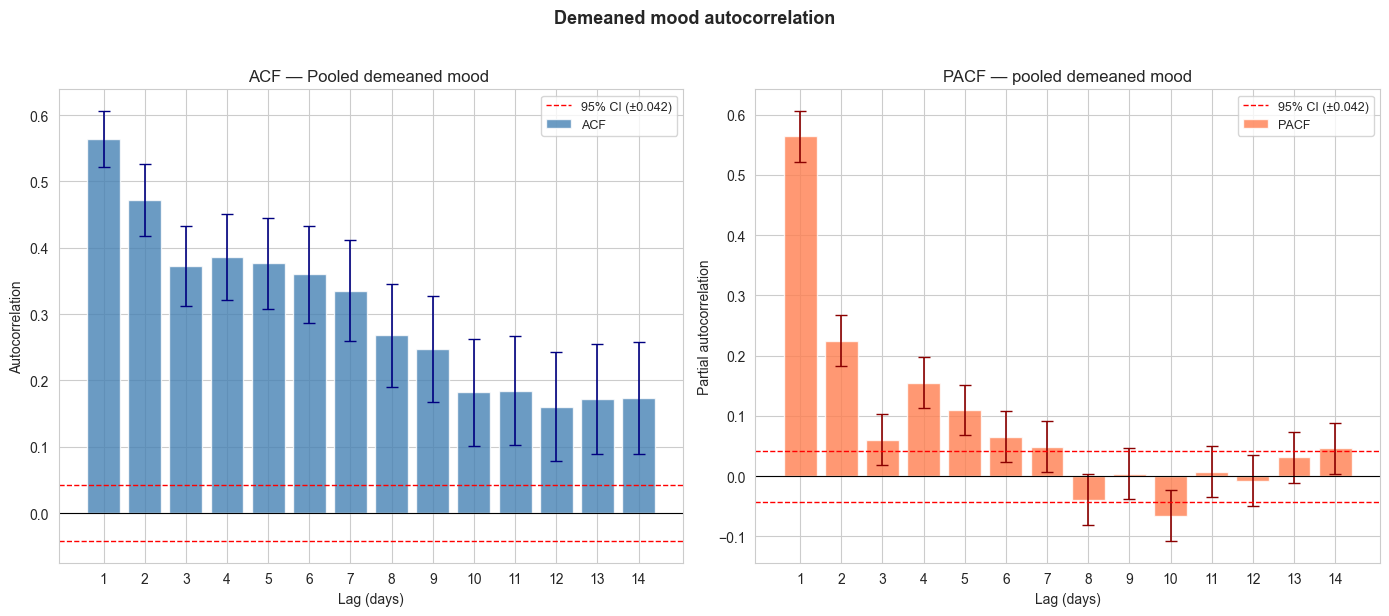

In [19]:
# 2. ACF and PACF
alpha = 0.05
n = len(pooled_mood)

acf_vals, acf_confint = acf(pooled_mood, nlags= 14, alpha=alpha)
pacf_vals, pacf_confint = pacf(pooled_mood, nlags= 14, alpha=alpha, method='ywmle')

# CI
acf_ci  = acf_confint[:, 1]  - acf_vals  
pacf_ci = pacf_confint[:, 1] - pacf_vals

lags = np.arange(14 + 1)

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# --- ACF ---
ax1 = fig.add_subplot(gs[0])
ax1.bar(lags[1:], acf_vals[1:], color='steelblue', alpha=0.8, label='ACF')
ax1.errorbar(lags[1:], acf_vals[1:], yerr=acf_ci[1:], fmt='none',
             color='navy', capsize=4, linewidth=1.2)
ax1.axhline(0, color='black', linewidth=0.8)
ci_bound = 1.96 / np.sqrt(n)
ax1.axhline( ci_bound, color='red', linestyle='--', linewidth=1, label=f'95% CI (±{ci_bound:.3f})')
ax1.axhline(-ci_bound, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('Lag (days)')
ax1.set_ylabel('Autocorrelation')
ax1.set_title('ACF — Pooled demeaned mood ')
ax1.set_xticks(lags[1:])
ax1.legend(fontsize=9)

# --- PACF ---
ax2 = fig.add_subplot(gs[1])
ax2.bar(lags[1:], pacf_vals[1:], color='coral', alpha=0.8, label='PACF')
ax2.errorbar(lags[1:], pacf_vals[1:], yerr=pacf_ci[1:], fmt='none',
             color='darkred', capsize=4, linewidth=1.2)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline( ci_bound, color='red', linestyle='--', linewidth=1, label=f'95% CI (±{ci_bound:.3f})')
ax2.axhline(-ci_bound, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('Lag (days)')
ax2.set_ylabel('Partial autocorrelation')
ax2.set_title('PACF — pooled demeaned mood')
ax2.set_xticks(lags[1:])
ax2.legend(fontsize=9)

plt.suptitle('Demeaned mood autocorrelation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [20]:
# Ljung-Box Test

lb_results = acorr_ljungbox(pooled_mood, lags=list(range(1, 14 + 1)), return_df=True)
lb_results.index.name = 'lag'
lb_results.columns  = ['LB_stat', 'p_value']
lb_results['significant'] = lb_results['p_value'] < 0.05

print("Ljung-Box test on pooled mood series:")
print(lb_results.to_string())


Ljung-Box test on pooled mood series:
         LB_stat        p_value  significant
lag                                         
1     686.448096  2.646645e-151         True
2    1166.642997  4.641859e-254         True
3    1466.223655   0.000000e+00         True
4    1787.602267   0.000000e+00         True
5    2093.790810   0.000000e+00         True
6    2373.614952   0.000000e+00         True
7    2617.209737   0.000000e+00         True
8    2772.562618   0.000000e+00         True
9    2904.506014   0.000000e+00         True
10   2976.200705   0.000000e+00         True
11   3050.007002   0.000000e+00         True
12   3105.896953   0.000000e+00         True
13   3169.923423   0.000000e+00         True
14   3235.382767   0.000000e+00         True


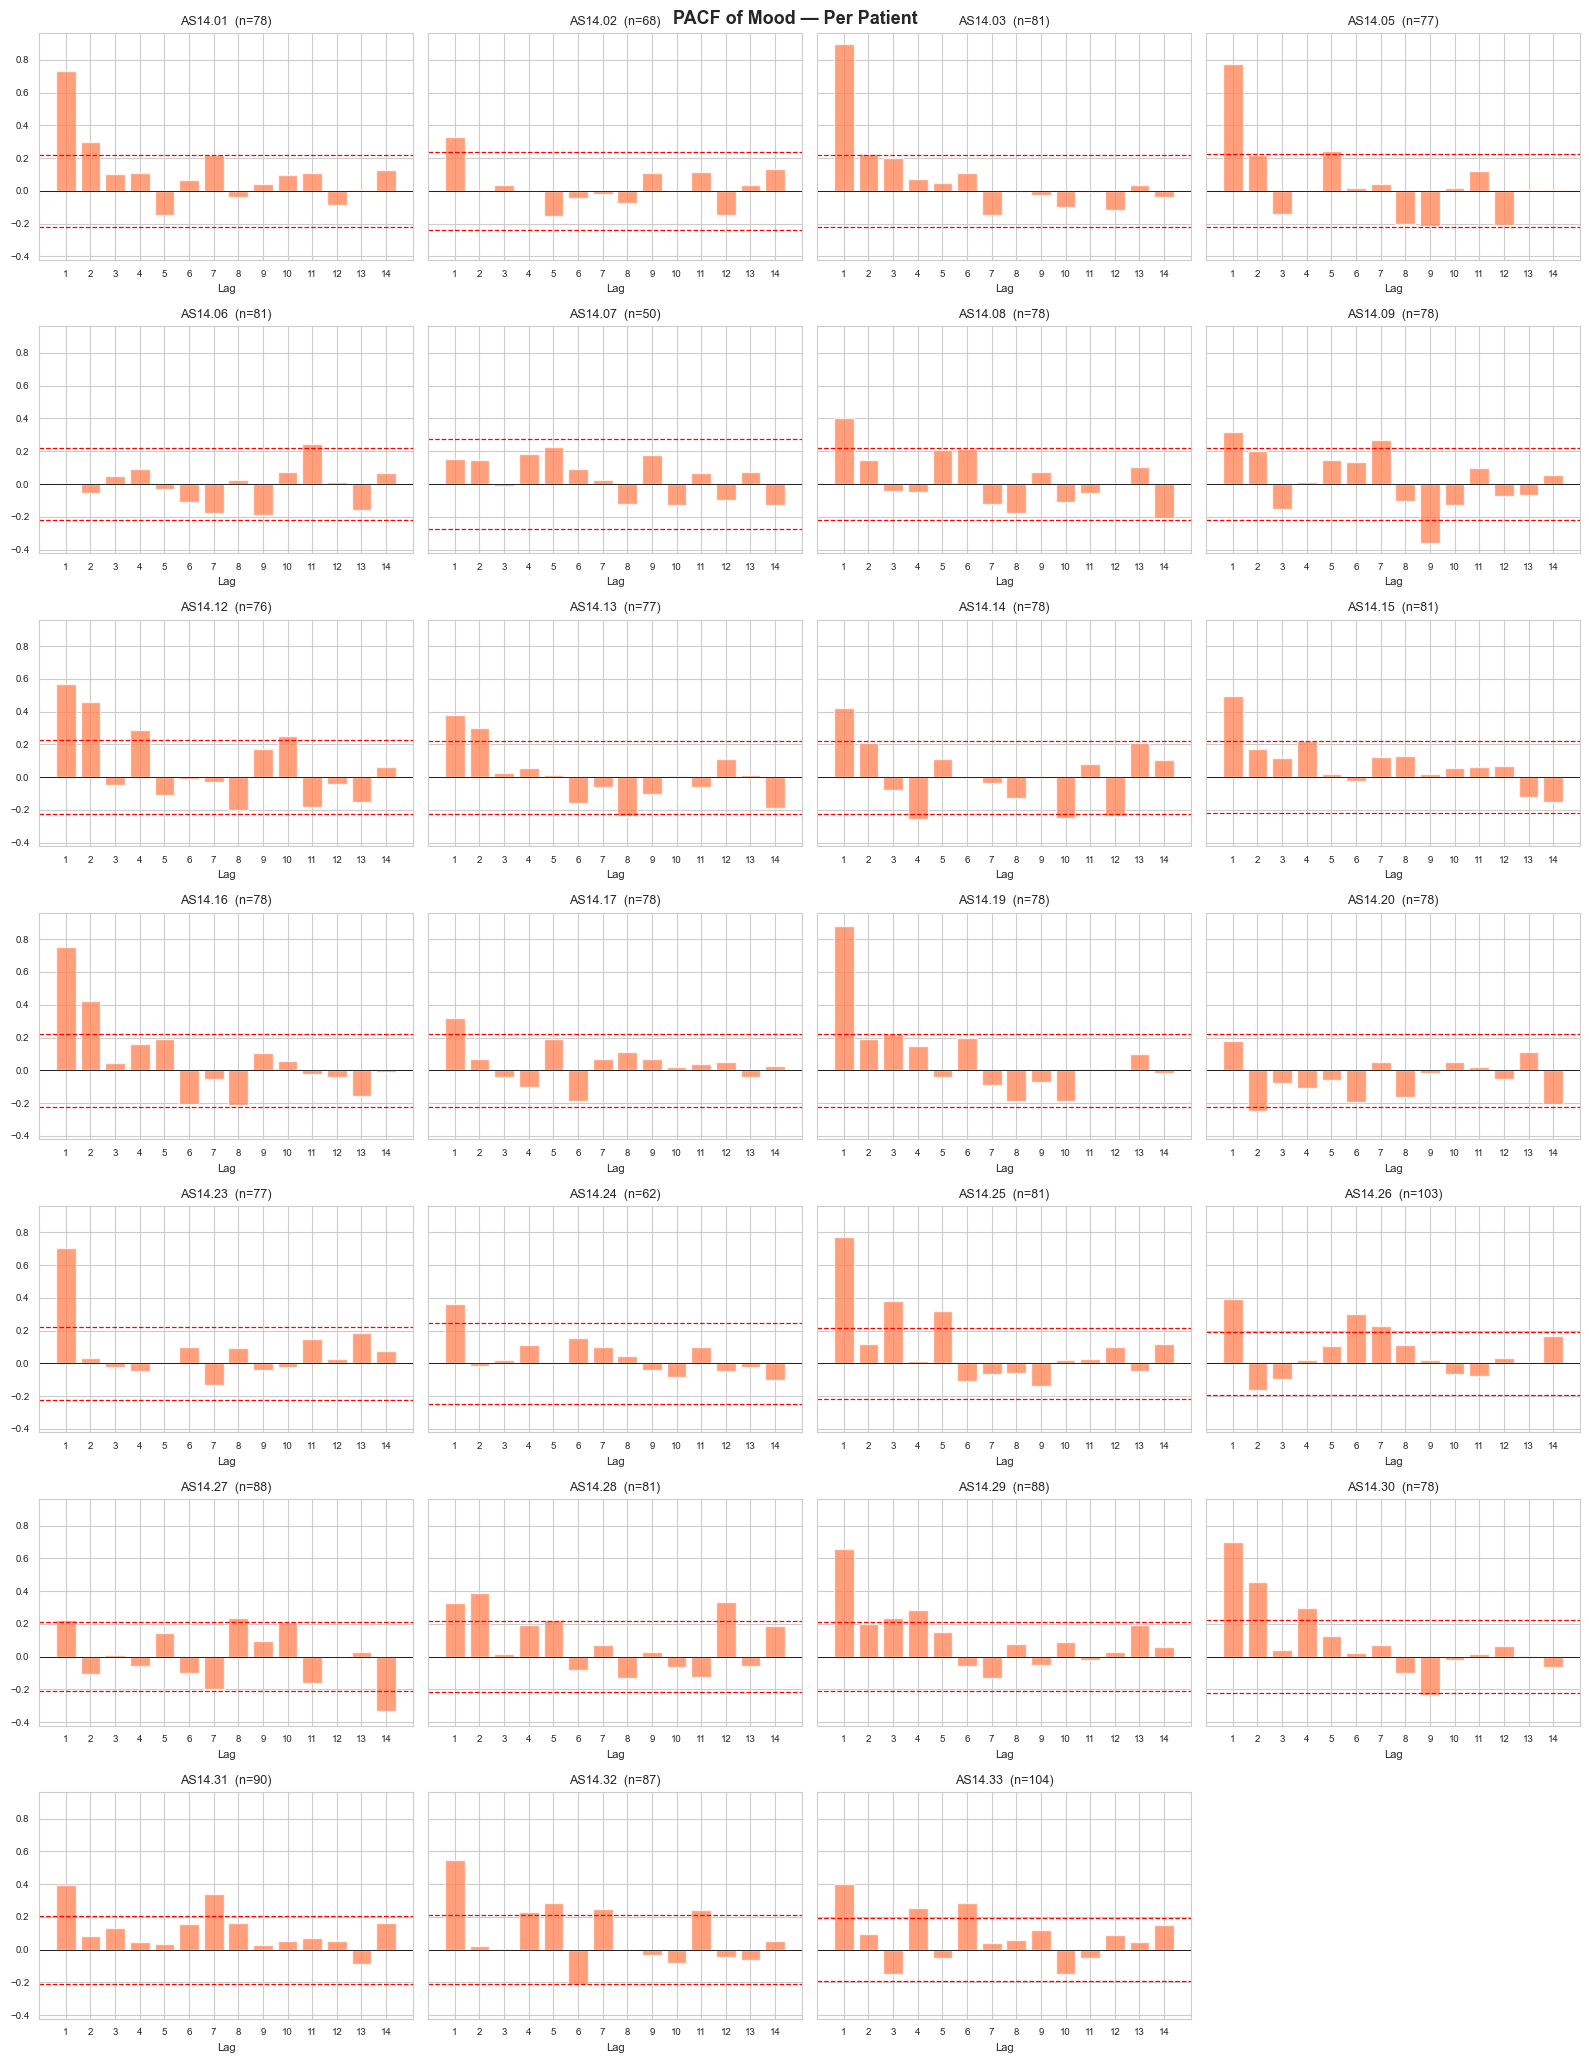

In [21]:
# Per-Patient PACF
# De meeste patienten tonen autocorrelatie in de eerste paar dagen, maar dit is niet consistent.
# Misschien beter niet laten zien?

pids = sorted(mood_series_by_patient.keys())
n_patients = len(pids)
ncols = 4
nrows = int(np.ceil(n_patients / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharey=True)
axes = axes.flatten()

for i, pid in enumerate(pids):
    s = mood_series_by_patient[pid]
    ax = axes[i]
    max_l = min(14, len(s) // 2 - 1)
    if max_l < 2:
        ax.set_title(f'{pid}\n(too short)', fontsize=9)
        ax.axis('off')
        continue
    try:
        pv, pv_ci = pacf(s, nlags=max_l, alpha= 0.05, method='ywmle')
    except Exception:
        ax.set_title(f'{pid}\n(error)', fontsize=9)
        ax.axis('off')
        continue

    l_range = np.arange(1, max_l + 1)
    ci_h = 1.96 / np.sqrt(len(s))
    ax.bar(l_range, pv[1:], color='coral', alpha=0.75)
    ax.axhline( ci_h, color='red', linestyle='--', linewidth=0.9)
    ax.axhline(-ci_h, color='red', linestyle='--', linewidth=0.9)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f'{pid}  (n={len(s)})', fontsize=9)
    ax.set_xlabel('Lag', fontsize=8)
    ax.set_xticks(l_range)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('PACF of Mood — Per Patient', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [22]:
features_df[["target_mood", "mood_mean"]]

,target_mood,mood_mean
0,6.250000,6.250000
1,6.250000,6.250000
2,6.250000,6.250000
3,6.333333,6.250000
4,6.327273,6.261905
...,...,...
1960,6.200000,5.983333
1961,8.200000,5.976190
1962,7.000000,6.290476
1963,6.800000,6.469048


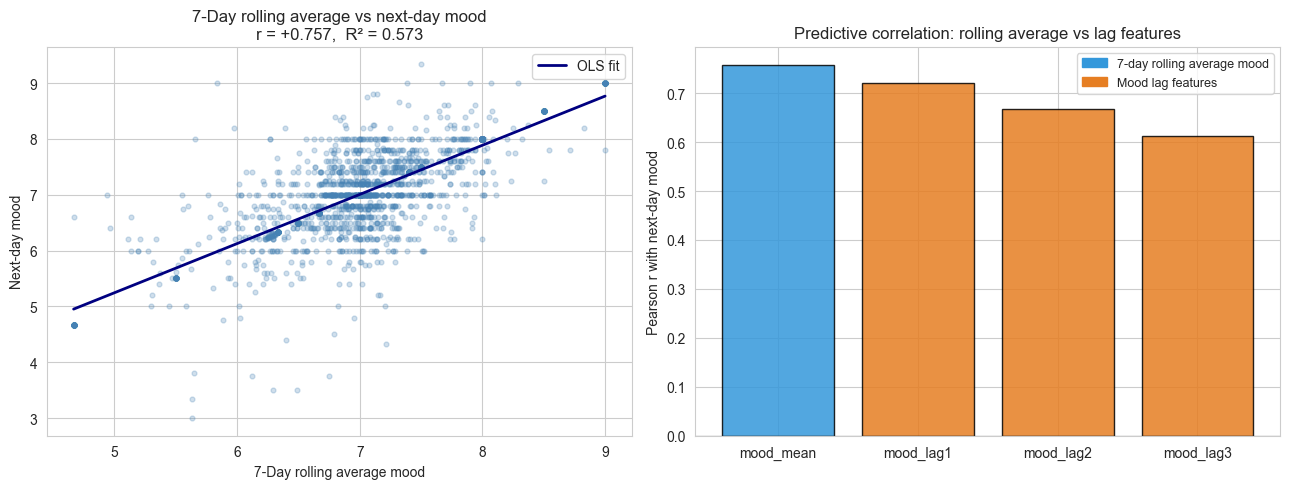

In [23]:
# 7-Day Rolling Mean + lags vs Next-Day Mood

from scipy import stats as scipy_stats

target_col = 'target_mood'
rolling_col = 'mood_mean'

lag_cols = [f'mood_lag{k}' for k in range(1, N_LAGS + 1)]
present   = [c for c in lag_cols if c in features_df.columns]

records = []
for col in present:
    valid = features_df[['target_mood', col]].dropna()
    r, p  = scipy_stats.pearsonr(valid['target_mood'], valid[col])
    records.append({
        'lag_feature': col,
        'n_pairs':     len(valid),
        'pearson_r':   round(r, 4),
        'p_value':     round(p, 6),
        'significant': p < 0.05,
        'r_squared':   round(r**2, 4)
    })

lag_summary = pd.DataFrame(records)

valid = features_df[[target_col, rolling_col]].dropna()
r_roll, p_roll = scipy_stats.pearsonr(valid[target_col], valid[rolling_col])
r2_roll = r_roll ** 2

all_rows = [{'lag_feature': rolling_col, 'pearson_r': r_roll,
             'r_squared': r2_roll, 'p_value': p_roll,
             'significant': p_roll < 0.05}]
all_rows += lag_summary.to_dict('records')

# ── Scatter plot: rolling mean vs target ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(valid[rolling_col], valid[target_col], alpha=0.25, s=12, color='steelblue')
m, b = np.polyfit(valid[rolling_col], valid[target_col], 1)
xs = np.linspace(valid[rolling_col].min(), valid[rolling_col].max(), 200)
axes[0].plot(xs, m * xs + b, color='navy', linewidth=2, label=f'OLS fit')
axes[0].set_xlabel('7-Day rolling average mood')
axes[0].set_ylabel('Next-day mood')
axes[0].set_title(f'7-Day rolling average vs next-day mood\nr = {r_roll:+.3f},  R² = {r2_roll:.3f}')
axes[0].legend()

# ── Bar chart comparing all predictors ────────────────────────────────────────
labels = [row['lag_feature'] for row in all_rows]
rs     = [row['pearson_r']   for row in all_rows]
colors = ['#3498db' if l == rolling_col else '#e67e22' for l in labels]

axes[1].bar(labels, rs, color=colors, edgecolor='black', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Pearson r with next-day mood')
axes[1].set_title('Predictive correlation: rolling average vs lag features')
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#3498db', label='7-day rolling average mood'),
    Patch(color='#e67e22', label='Mood lag features')
], fontsize=9)

plt.tight_layout()
plt.show()


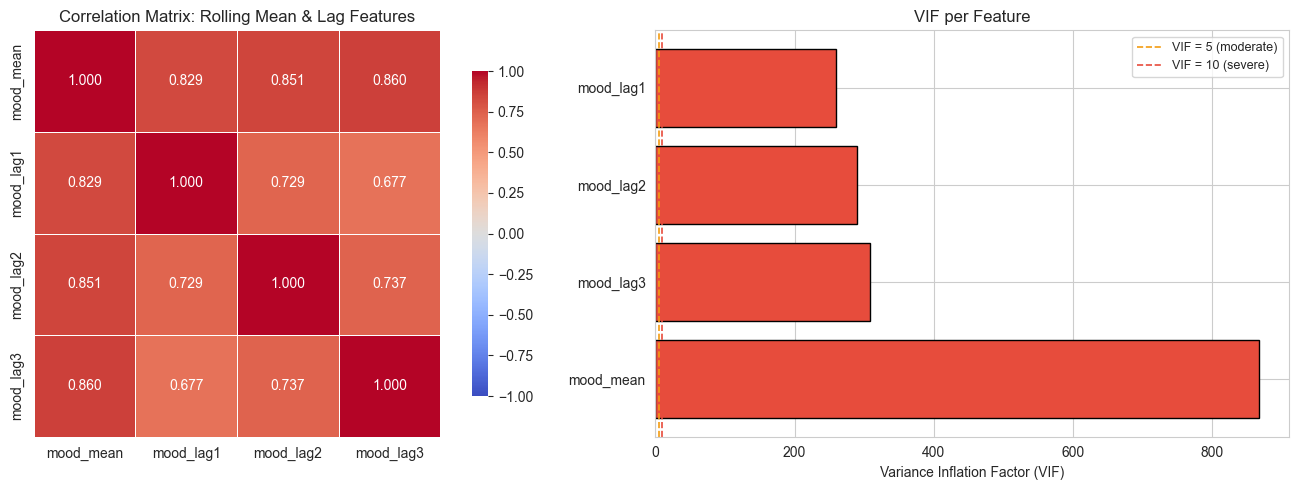

  feature        VIF
mood_mean 866.863889
mood_lag3 308.627693
mood_lag2 289.369486
mood_lag1 259.213930


In [24]:
# Multicollinearity Check
from statsmodels.stats.outliers_influence import variance_inflation_factor

mc_cols = ['mood_mean'] + [f'mood_lag{k}' for k in range(1, N_LAGS + 1)]
mc_df   = features_df[mc_cols].dropna()

corr_matrix = mc_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix: Rolling Mean & Lag Features')

# Variance inflation factor (VIF)
vif_data = pd.DataFrame({
    'feature': mc_cols,
    'VIF': [variance_inflation_factor(mc_df.values, i) for i in range(len(mc_cols))]
}).sort_values('VIF', ascending=False)

colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
          for v in vif_data['VIF']]
axes[1].barh(vif_data['feature'], vif_data['VIF'], color=colors, edgecolor='black')
axes[1].axvline(5,  color='#f39c12', linestyle='--', linewidth=1.2, label='VIF = 5 (moderate)')
axes[1].axvline(10, color='#e74c3c', linestyle='--', linewidth=1.2, label='VIF = 10 (severe)')
axes[1].set_xlabel('Variance Inflation Factor (VIF)')
axes[1].set_title('VIF per Feature')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(vif_data.to_string(index=False))

In [30]:
features_df["mood_mean"]

0       6.250000
1       6.250000
2       6.250000
3       6.250000
4       6.261905
          ...   
1960    5.983333
1961    5.976190
1962    6.290476
1963    6.469048
1964    6.607143
Name: mood_mean, Length: 1965, dtype: float64

## Train-test split

In [ ]:
# Add the mood_mean to the dataset. This means that i'll have to 
merged_df = daily_df.merge(features_df[['id', 'date', 'mood_mean']], on=['id', 'date'], how='inner')

In [56]:
def split_per_id(df, test_size=0.2):
    train_list = []
    test_list = []

    for _, group in df.groupby('id'):
        group = group.sort_values('date')
        split_idx = int(len(group) * (1 - test_size))
        
        train_list.append(group.iloc[:split_idx])
        test_list.append(group.iloc[split_idx:])
    
    return pd.concat(train_list), pd.concat(test_list)

train, test = split_per_id(merged_df)

In [ ]:
WINDOW_SIZE = 7

feature_cols = [c for c in merged_df.columns if c not in ['id', 'date', 'target_mood']]

train_rows, test_rows = [], []

for pid, group in merged_df.groupby('id'):
    group = group.sort_values('date').reset_index(drop=True)
    n = len(group)

    for start in range(0, n - WINDOW_SIZE):
        window_end  = start + WINDOW_SIZE       
        target_idx  = window_end            

        if target_idx >= n:
            break

        # One train window: all rows inside the window
        train_slice = group.iloc[start:window_end].copy()

        # One test row: the target immediately after the window
        test_row = group.iloc[[target_idx]].copy()

        train_rows.append(train_slice)
        test_rows.append(test_row)

train_df = pd.concat(train_rows, ignore_index=True)
test_df  = pd.concat(test_rows,  ignore_index=True)

X_train = train_df.drop('mood', axis = 1)
y_train = train_df['mood']

X_test  = test_df.drop('mood', axis = 1)
y_test  = test_df['mood']

train_df : (12432, 16)  |  test_df : (1776, 16)
Unique IDs in train : 27
